# Classification Evaluation


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [495]:
data_raw = pd.read_csv("heart.csv")
data = data_raw.copy()

In [496]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
nans = data.isna().sum()
totalNans = data.isna().sum().sum()

print(totalNans)
nans

0


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [ ]:
nulls = data.isnull().sum()
totalNulls = data.isnull().sum().sum()

print(totalNulls)
nulls

0


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [ ]:
zeros = (data == 0).sum()
totalZeros = (data == 0).sum().sum()

print(totalZeros)
zeros

1655


Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS         704
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak           368
ST_Slope            0
HeartDisease      410
dtype: int64

In [500]:
data[data.FastingBS == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
912,57,F,ASY,140,241,0,Normal,123,Y,0.2,Flat,1
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [501]:
# data.replace({"Age":0, "RestingBP":0, "Cholesterol": 0, "MaxHR":0, "FastingBS":0}, np.nan,inplace=True)

In [502]:
data.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [ ]:
data_categorical = data.select_dtypes("object")
data_numeric = data.select_dtypes(["float64", "int64"]).iloc[:, :-1]
y = data.iloc[:, -1].values

In [504]:
data_categorical

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


In [505]:
data_categorical.head()

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up


In [506]:
data_categorical.nunique()

Sex               2
ChestPainType     4
RestingECG        3
ExerciseAngina    2
ST_Slope          3
dtype: int64

In [507]:
from sklearn.preprocessing import LabelEncoder

In [508]:
label_enc = LabelEncoder()
data_categorical = data_categorical.apply(label_enc.fit_transform)

In [509]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
data_categorical_bin = data_categorical[["Sex", "ExerciseAngina"]]
ohe_enc = OneHotEncoder()

data_ohe = ohe_enc.fit_transform(
    data_categorical[["ChestPainType", "RestingECG", "ST_Slope"]].values).toarray()

In [511]:
type(data_categorical_bin.values)

numpy.ndarray

In [ ]:

final_array = np.concatenate(
    [data_numeric.values, data_categorical_bin.values, data_ohe], axis=1)


# Convert to DataFrame
data = pd.DataFrame(final_array)

In [513]:
from sklearn.model_selection import train_test_split

In [514]:
from sklearn.preprocessing import MinMaxScaler

In [515]:
data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,40.0,140.0,289.0,0.0,172.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49.0,160.0,180.0,0.0,156.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37.0,130.0,283.0,0.0,98.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,48.0,138.0,214.0,0.0,108.0,1.5,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,54.0,150.0,195.0,0.0,122.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45.0,110.0,264.0,0.0,132.0,1.2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
914,68.0,144.0,193.0,1.0,141.0,3.4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
915,57.0,130.0,131.0,0.0,115.0,1.2,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
916,57.0,130.0,236.0,0.0,174.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
scaler = MinMaxScaler()
transform_data = scaler.fit_transform(data)


# Convert to DataFrame
data = pd.DataFrame(transform_data)

In [517]:
data.isna().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
dtype: int64

In [518]:
X = data

In [519]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3)

In [520]:
from sklearn import metrics

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [522]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()
k_value = range(1, 65, 2)

params = {
    'n_neighbors': k_value,
    'p': range(2, 10),    # prefer **2
    'weights': ['uniform', 'distance']
}
# reduce std with shuffleSplit
cv = ShuffleSplit(n_splits=5, test_size=.25, random_state=567)
clf = GridSearchCV(knn, param_grid=params, scoring="accuracy",
                   cv=cv, verbose=1, return_train_score=True)

In [524]:
# best K neighbors: sqrt(N)/2 .... sqrt(N)*2

In [ ]:
clf.fit(X, y)

Fitting 5 folds for each of 512 candidates, totalling 2560 fits


GridSearchCV(cv=ShuffleSplit(n_splits=5, random_state=567, test_size=0.25, train_size=None),
             estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 65, 2), 'p': range(2, 10),
                         'weights': ['uniform', 'distance']},
             return_train_score=True, scoring='accuracy', verbose=1)

In [526]:
print(clf.best_score_)
print(clf.best_estimator_)
print(clf.best_params_)
print(clf.best_index_)

0.8626086956521739
KNeighborsClassifier(n_neighbors=19, weights='distance')
{'n_neighbors': 19, 'p': 2, 'weights': 'distance'}
145


In [ ]:
knn = KNeighborsClassifier()
k_value = range(1, 65, 2)

params = {
    'n_neighbors': range(1, 30, 2),
    'p': range(2, 10),
    'weights': ['uniform', 'distance']
}
# reduce std with shuffleSplit
cv = ShuffleSplit(n_splits=5, test_size=.25, random_state=567)
clf_r = RandomizedSearchCV(knn, param_distributions=params, scoring="accuracy",
                           cv=cv, verbose=1, n_iter=100, return_train_score=True)

In [ ]:
clf_r.fit(X, y)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=ShuffleSplit(n_splits=5, random_state=567, test_size=0.25, train_size=None),
                   estimator=KNeighborsClassifier(), n_iter=100,
                   param_distributions={'n_neighbors': range(1, 30, 2),
                                        'p': range(2, 10),
                                        'weights': ['uniform', 'distance']},
                   return_train_score=True, scoring='accuracy', verbose=1)

In [529]:
clf_r.best_estimator_

KNeighborsClassifier(n_neighbors=19, p=3, weights='distance')

In [530]:
print(clf.best_score_)

0.8626086956521739


In [531]:
y_pred = clf_r.predict(X)

In [532]:
print(metrics.classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       410
           1       1.00      1.00      1.00       508

    accuracy                           1.00       918
   macro avg       1.00      1.00      1.00       918
weighted avg       1.00      1.00      1.00       918



In [533]:
len(X)

918

In [534]:
clf.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_n_neighbors', 'param_p', 'param_weights', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'split3_train_score', 'split4_train_score', 'mean_train_score', 'std_train_score'])

In [535]:
clf_r.cv_results_['params']

[{'weights': 'uniform', 'p': 5, 'n_neighbors': 25},
 {'weights': 'uniform', 'p': 4, 'n_neighbors': 25},
 {'weights': 'distance', 'p': 6, 'n_neighbors': 5},
 {'weights': 'distance', 'p': 8, 'n_neighbors': 19},
 {'weights': 'uniform', 'p': 4, 'n_neighbors': 7},
 {'weights': 'uniform', 'p': 5, 'n_neighbors': 9},
 {'weights': 'distance', 'p': 8, 'n_neighbors': 21},
 {'weights': 'distance', 'p': 9, 'n_neighbors': 19},
 {'weights': 'distance', 'p': 6, 'n_neighbors': 29},
 {'weights': 'distance', 'p': 5, 'n_neighbors': 13},
 {'weights': 'uniform', 'p': 2, 'n_neighbors': 9},
 {'weights': 'uniform', 'p': 3, 'n_neighbors': 19},
 {'weights': 'distance', 'p': 3, 'n_neighbors': 21},
 {'weights': 'uniform', 'p': 8, 'n_neighbors': 9},
 {'weights': 'uniform', 'p': 6, 'n_neighbors': 21},
 {'weights': 'distance', 'p': 7, 'n_neighbors': 13},
 {'weights': 'uniform', 'p': 2, 'n_neighbors': 13},
 {'weights': 'distance', 'p': 5, 'n_neighbors': 15},
 {'weights': 'uniform', 'p': 5, 'n_neighbors': 29},
 {'weigh

In [ ]:
# find best scores

test_scores = clf.cv_results_['mean_test_score']
train_scores = clf.cv_results_['mean_train_score']
train_test_distance = train_scores / test_scores

In [537]:
test_scores.max()

np.float64(0.8626086956521739)

In [538]:
arg_min_dist = train_test_distance.argmin()
arg_min_dist

np.int64(364)

In [539]:
test_scores[arg_min_dist]

np.float64(0.8495652173913044)

In [540]:
train_scores[arg_min_dist]

np.float64(0.8636627906976744)

In [541]:
clf_r.cv_results_['params'][12]

{'weights': 'distance', 'p': 3, 'n_neighbors': 21}

In [ ]:
# k= k_values[arg_min_dist]
# k
clf_params = clf.cv_results_["params"]

clf_params[arg_min_dist]

{'n_neighbors': 45, 'p': 8, 'weights': 'uniform'}

In [ ]:
# k_value[arg_min_dist]

In [544]:
clf.cv_results_["params"]

[{'n_neighbors': 1, 'p': 2, 'weights': 'uniform'},
 {'n_neighbors': 1, 'p': 2, 'weights': 'distance'},
 {'n_neighbors': 1, 'p': 3, 'weights': 'uniform'},
 {'n_neighbors': 1, 'p': 3, 'weights': 'distance'},
 {'n_neighbors': 1, 'p': 4, 'weights': 'uniform'},
 {'n_neighbors': 1, 'p': 4, 'weights': 'distance'},
 {'n_neighbors': 1, 'p': 5, 'weights': 'uniform'},
 {'n_neighbors': 1, 'p': 5, 'weights': 'distance'},
 {'n_neighbors': 1, 'p': 6, 'weights': 'uniform'},
 {'n_neighbors': 1, 'p': 6, 'weights': 'distance'},
 {'n_neighbors': 1, 'p': 7, 'weights': 'uniform'},
 {'n_neighbors': 1, 'p': 7, 'weights': 'distance'},
 {'n_neighbors': 1, 'p': 8, 'weights': 'uniform'},
 {'n_neighbors': 1, 'p': 8, 'weights': 'distance'},
 {'n_neighbors': 1, 'p': 9, 'weights': 'uniform'},
 {'n_neighbors': 1, 'p': 9, 'weights': 'distance'},
 {'n_neighbors': 3, 'p': 2, 'weights': 'uniform'},
 {'n_neighbors': 3, 'p': 2, 'weights': 'distance'},
 {'n_neighbors': 3, 'p': 3, 'weights': 'uniform'},
 {'n_neighbors': 3, 'p

In [ ]:
# k_values[30]

NameError: name 'k_values' is not defined

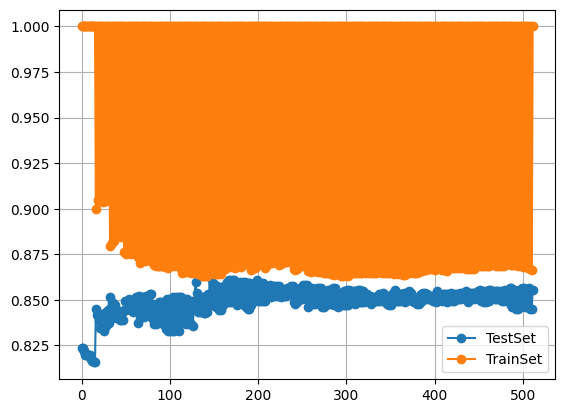

In [ ]:
plt.plot(range(len(test_scores)), test_scores, '-o', label='TestSet')
plt.plot(range(len(test_scores)), train_scores, '-o', label="TrainSet")
plt.legend()
plt.grid(True)
plt.show()

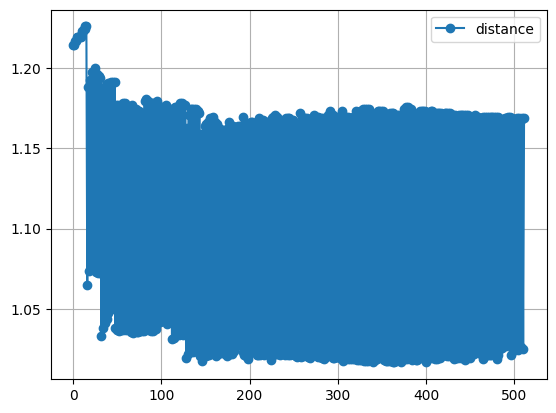

In [ ]:
# plt.plot(k_values, train_test_distance, '-o', label = 'distance')
plt.plot(range(len(test_scores)), train_test_distance, '-o', label='distance')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
knn_final = KNeighborsClassifier(n_neighbors=47)
knn_final.fit(X, y)

KNeighborsClassifier(n_neighbors=47)

In [549]:
y_pred = knn_final.predict(X)
printmetrics.classification_report(y, y_pred)

NameError: name 'printmetrics' is not defined